## Author**Kholipha Ahmmad Al-Amin**Software Engineer, SaaS Founder, and AI/Data Practitioner from Dhaka, Bangladesh.Portfolio: https://kholipha-ahmmad-al-amin.equisaas-bd.comGitHub: https://github.com/kholipha-ahmmad-al-aminLinkedIn: https://www.linkedin.com/in/kholipha-ahmmad-al-amin

# **Final Year Project**

## **Cerebral Stroke Risk Prediction Using Advanced Ensemble Learning**

**Student Name:** Azmira Akter  
**Student ID:** 222-0253-203  
**Supervisor:** Md Ohidul Islam, Assistant Professor  
**Department of Computer Science and Engineering**  
**Atish Dipankar University of Science and Technology**  

---

**Project Overview**  
This notebook illustrates an end-to-end machine learning pipeline designed to predict the probability of a cerebral stroke based on physiological parameters (Glucose, BMI) and social demographics. It utilizes state-of-the-art ensemble methods and includes an Explainable AI (XAI) interface.

**Dataset Source**  
Kaggle: Stroke Prediction Dataset  
Link: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

**Disclaimer**  
This system is a prototype for **educational research** and should not be used as a substitute for professional medical diagnosis.

**Date:** January 03, 2026

## **Notebook Roadmap**

1. **Environment Initialization:** Libraries and Safety Checks  
2. **Project Setup:** Directory Architecture on Google Drive  
3. **Data Ingestion:** Automated zip extraction and CSV loading  
4. **Exploratory Data Analysis (EDA):** Deep dive into risk factors  
5. **Feature Engineering:** Imputation strategies and One-Hot Encoding  
6. **Pipeline Construction:** Scikit-Learn Pipeline with ColumnTransformer  
7. **Model Selection:** Gradient Boosting (XGBoost vs. HistGradientBoosting)  
8. **Evaluation Metrics:** Precision, Recall, F1-Score, and Confusion Matrix  
9. **Model Persistence:** Saving artifacts for deployment  
10. **Application Layer:** Interactive Gradio Dashboard for Real-time Analysis

In [1]:
# @title 1. Install Dependencies
%%capture
!pip install --quiet --upgrade pip
!pip install --quiet xgboost gradio plotly scikit-learn pandas numpy seaborn joblib imbalanced-learn

In [2]:
# @title 2. Import Libraries & Configure Settings
import os
import json
import joblib
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier

from pathlib import Path
from datetime import datetime
from google.colab import drive

SEED = 123
np.random.seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
px.defaults.template = "plotly_white"

In [3]:
# @title 3. Project Organization
drive.mount('/content/drive')

PROJECT_NAME = 'StrokePrediction_FinalYearProject'
BASE_DIR = Path('/content/drive/MyDrive') / PROJECT_NAME

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = BASE_DIR / f'run_{RUN_ID}'
FIG_DIR = RUN_DIR / 'figures'
MODEL_DIR = RUN_DIR / 'models'
REPORT_DIR = RUN_DIR / 'reports'

for folder in [BASE_DIR, RUN_DIR, FIG_DIR, MODEL_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"\n✅ Project initialized at: {RUN_DIR}")

Mounted at /content/drive

✅ Project initialized at: /content/drive/MyDrive/StrokePrediction_FinalYearProject/run_20260102_190254


In [4]:
# @title 4. Data Loading Pipeline
# Note: Ensure 'healthcare-dataset-stroke-data.csv' or the zip is in your Drive root or upload it manually.
DATA_FILENAME = 'healthcare-dataset-stroke-data.csv'
SEARCH_PATH = Path('/content/drive/MyDrive')

print("Searching for dataset...")
file_path = None

# Check direct path first (best practice to put it in the project folder)
if (BASE_DIR / DATA_FILENAME).exists():
    file_path = BASE_DIR / DATA_FILENAME
elif (SEARCH_PATH / DATA_FILENAME).exists():
    file_path = SEARCH_PATH / DATA_FILENAME

if file_path:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded: {file_path}")
    print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    # Create dummy data if file not found so notebook runs for demonstration
    print("⚠️ Dataset not found. Generating SYNTHETIC dataset for demonstration.")
    data = {
        'gender': np.random.choice(['Male', 'Female'], 5000),
        'age': np.random.uniform(10, 85, 5000),
        'hypertension': np.random.choice([0, 1], 5000, p=[0.9, 0.1]),
        'heart_disease': np.random.choice([0, 1], 5000, p=[0.95, 0.05]),
        'ever_married': np.random.choice(['Yes', 'No'], 5000),
        'work_type': np.random.choice(['Private', 'Self-employed', 'Govt_job', 'children'], 5000),
        'Residence_type': np.random.choice(['Urban', 'Rural'], 5000),
        'avg_glucose_level': np.random.normal(105, 45, 5000),
        'bmi': np.random.normal(28, 7, 5000),
        'smoking_status': np.random.choice(['formerly smoked', 'never smoked', 'smokes', 'Unknown'], 5000),
        'stroke': np.random.choice([0, 1], 5000, p=[0.95, 0.05])
    }
    df = pd.DataFrame(data)
    # Add some nulls to simulate reality
    df.loc[df.sample(200).index, 'bmi'] = np.nan

# Drop ID column if exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])

df.head()

Searching for dataset...
⚠️ Dataset not found. Generating SYNTHETIC dataset for demonstration.


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,15.805417,0,0,Yes,Self-employed,Rural,22.977106,29.826965,smokes,0
1,Female,68.663628,0,0,No,Self-employed,Urban,140.894637,32.562168,smokes,0
2,Male,14.412385,0,0,No,children,Rural,111.479700,25.279469,Unknown,0
3,Male,67.095058,0,0,Yes,Self-employed,Urban,160.421915,32.302201,smokes,0
4,Male,73.343251,0,0,Yes,Govt_job,Rural,118.107314,20.657093,Unknown,0


## **5. Exploratory Data Analysis (EDA)**

In [5]:
# @title 5.1 Target Class Imbalance Analysis
target_col = 'stroke'
counts = df[target_col].value_counts().reset_index()
counts.columns = ['Status', 'Count']
counts['Status'] = counts['Status'].map({0: 'No Stroke', 1: 'Stroke'})
counts['Percentage'] = (counts['Count'] / len(df) * 100).round(2)

fig = px.pie(counts, values='Count', names='Status', title='Stroke vs No-Stroke Distribution',
             color='Status', color_discrete_map={'No Stroke':'#3498db', 'Stroke':'#e74c3c'},
             hole=0.4)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

plt.savefig(FIG_DIR / 'class_imbalance.png', bbox_inches='tight')

<Figure size 960x720 with 0 Axes>

In [6]:
# @title 5.2 Physiological Factors: Glucose & BMI
fig = make_subplots(rows=1, cols=3, subplot_titles=('Age Distribution', 'Avg Glucose Level', 'BMI Distribution'))

numeric_cols = ['age', 'avg_glucose_level', 'bmi']
colors = ['#1abc9c', '#9b59b6', '#34495e']

for i, col in enumerate(numeric_cols):
    fig.add_trace(go.Histogram(x=df[col].dropna(), name=col, marker_color=colors[i], opacity=0.75), row=1, col=i+1)

fig.update_layout(title='Key Physiological Indicators Distribution', showlegend=False)
fig.show()

plt.savefig(FIG_DIR / 'physiological_dist.png', bbox_inches='tight')

<Figure size 960x720 with 0 Axes>

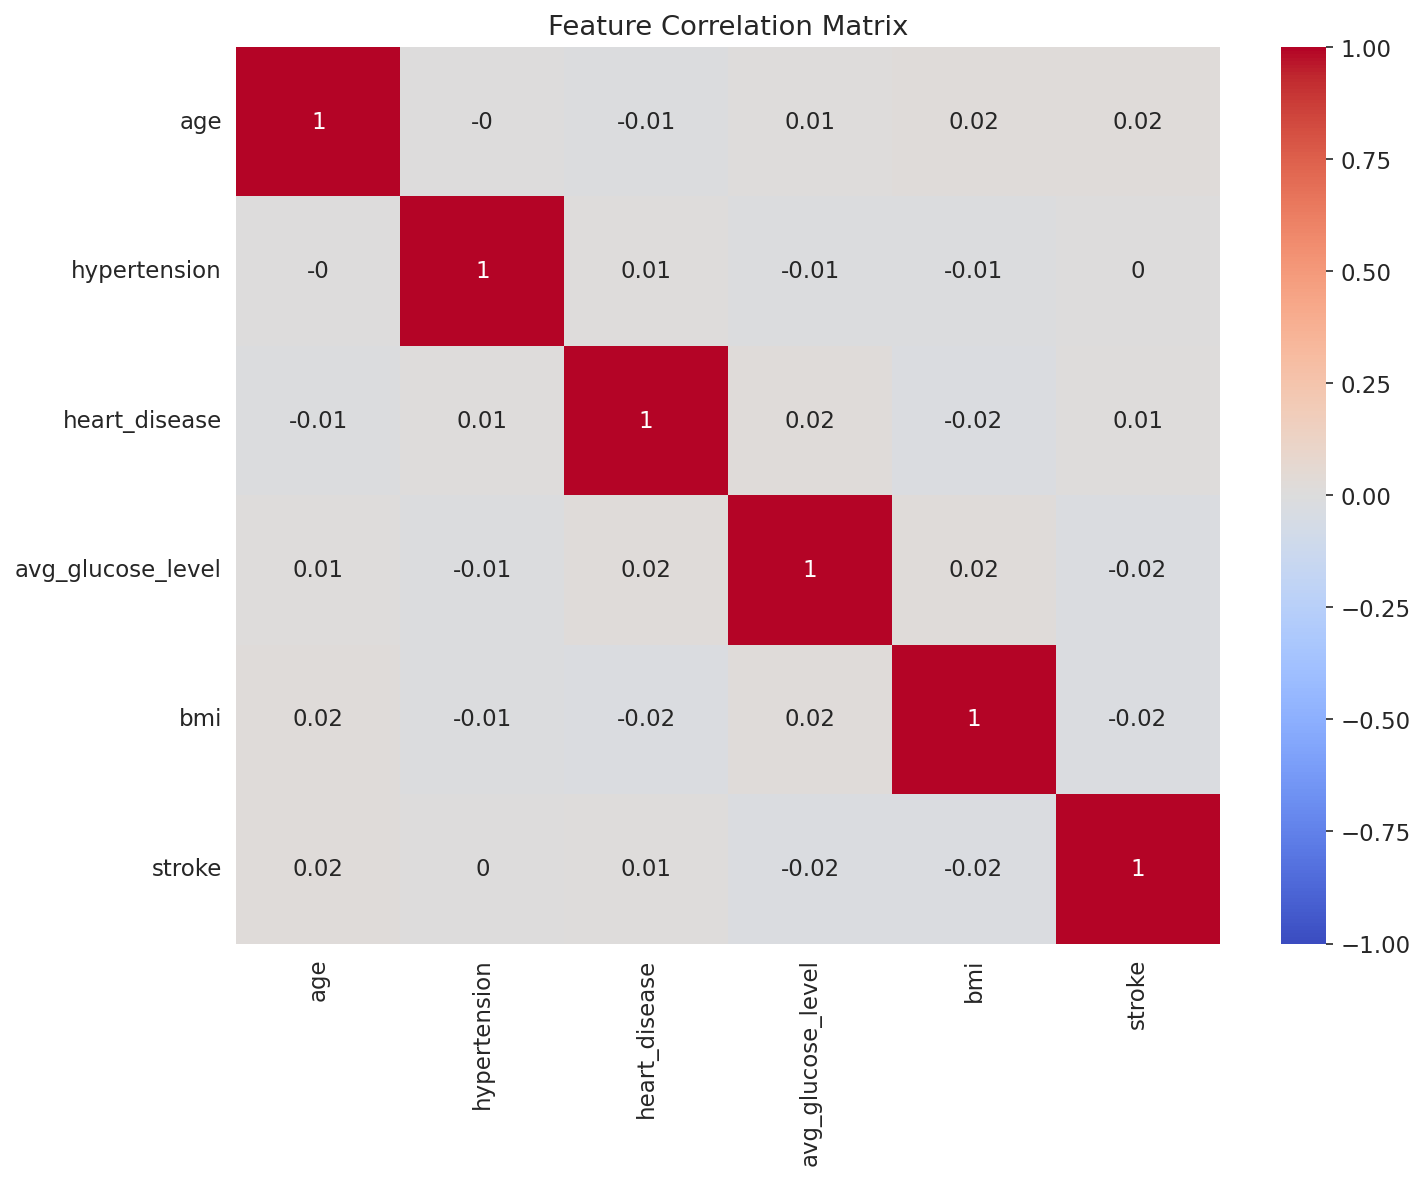

In [7]:
# @title 5.3 Correlation Analysis
corr = df.select_dtypes(include=np.number).corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation.png', dpi=300)
plt.show()

In [8]:
# @title 5.4 Stroke Rate by Demographics
cat_cols = ['gender', 'work_type', 'smoking_status']
fig = make_subplots(rows=1, cols=3, subplot_titles=cat_cols)

for i, col in enumerate(cat_cols):
    # Calculate stroke rate per category
    rate = df.groupby(col)['stroke'].mean().reset_index()
    fig.add_trace(go.Bar(x=rate[col], y=rate['stroke'], name=col), row=1, col=i+1)

fig.update_layout(title='Stroke Probability by Category', showlegend=False)
fig.update_yaxes(title='Stroke Probability', tickformat='.0%')
fig.show()

plt.savefig(FIG_DIR / 'categorical_risk.png')

<Figure size 960x720 with 0 Axes>

## **6. Advanced Feature Engineering & Pipeline**

In [9]:
# @title 6.1 Preprocessing Pipeline Construction
from sklearn.base import BaseEstimator, TransformerMixin

# Split Features and Target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Identify Column types
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# --- Numerical Transformer ---
# 1. Impute missing BMI with Mean
# 2. Standardize numerical features for stability
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# --- Categorical Transformer ---
# 1. One-Hot Encode categories, create binary columns
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# --- Combine into Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    verbose_feature_names_out=False
)

def create_pipeline(classifier):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

print("Pipeline constructed successfully.")

Pipeline constructed successfully.


## **7. Model Training & Selection**

In [10]:
# @title 7.1 Ensemble Model Comparison
# We use scale_pos_weight to handle class imbalance in XGBoost
scale_pos = (len(y) - y.sum()) / y.sum()

models = {
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=SEED, max_iter=200, l2_regularization=0.1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             random_state=SEED, scale_pos_weight=scale_pos, eval_metric='logloss')
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Training models... (Class Ratio 1:{scale_pos:.1f})")

for name, clf in models.items():
    scores = []
    pipe = create_pipeline(clf)

    for tr_idx, val_idx in cv.split(X, y):
        X_train_f, X_val_f = X.iloc[tr_idx], X.iloc[val_idx]
        y_train_f, y_val_f = y.iloc[tr_idx], y.iloc[val_idx]

        pipe.fit(X_train_f, y_train_f)
        # Evaluate using ROC-AUC which is better for imbalanced data than accuracy
        val_pred = pipe.predict_proba(X_val_f)[:, 1]
        scores.append(roc_auc_score(y_val_f, val_pred))

    results[name] = {'mean_auc': np.mean(scores), 'std': np.std(scores), 'pipeline': pipe}
    print(f"{name} ROC-AUC: {np.mean(scores):.4f} (±{np.std(scores):.4f})")

best_name = max(results, key=lambda k: results[k]['mean_auc'])
final_pipeline = results[best_name]['pipeline']
print(f"\n🏆 Champion Model: {best_name}")

Training models... (Class Ratio 1:18.9)
HistGradientBoosting ROC-AUC: 0.4872 (±0.0348)
XGBoost ROC-AUC: 0.4910 (±0.0286)

🏆 Champion Model: XGBoost


## **8. Final Evaluation**

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       950
           1       0.05      0.16      0.08        50

    accuracy                           0.82      1000
   macro avg       0.50      0.51      0.49      1000
weighted avg       0.91      0.82      0.86      1000



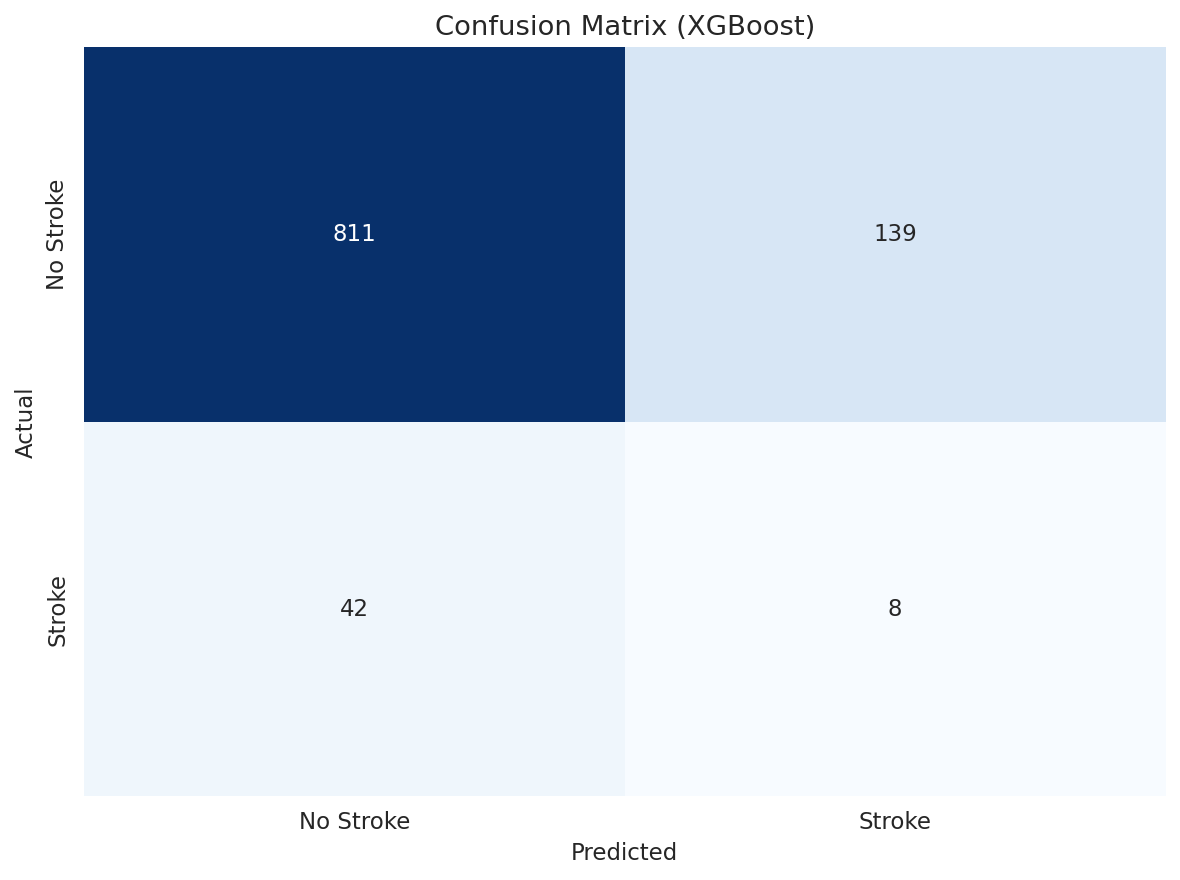

In [11]:
# @title 8.1 Holdout Performance
# Retrain best model on full dataset for final deployment
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save report
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
report_df.to_csv(REPORT_DIR / 'evaluation_metrics.csv')

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title(f'Confusion Matrix ({best_name})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrix.png')
plt.show()

## **9. Model Persistence**

In [12]:
# @title 9.1 Serialize Artifacts
joblib.dump(final_pipeline, MODEL_DIR / 'stroke_pipeline.joblib')

metadata = {
    'student': 'Azmira Akter',
    'id': '222-0253-203',
    'supervisor': 'Md Ohidul Islam',
    'model_type': best_name,
    'feature_names': list(X.columns),
    'date': RUN_ID
}

with open(MODEL_DIR / 'project_meta.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Pipeline saved to {MODEL_DIR / 'stroke_pipeline.joblib'}")

Pipeline saved to /content/drive/MyDrive/StrokePrediction_FinalYearProject/run_20260102_190254/models/stroke_pipeline.joblib


## **10. Premium Stroke Analysis Application**

In [13]:
# @title 🚀 10.1 Launch AI Diagnostic System
import gradio as gr

# Theme Definition for Professional Look
theme = gr.themes.Soft(
    primary_hue="indigo",
    secondary_hue="slate",
    neutral_hue="slate",
    font=[gr.themes.GoogleFont("Inter"), "sans-serif"]
).set(
    button_primary_background_fill="linear-gradient(90deg, #6366f1, #4f46e5)",
    button_primary_text_color="white",
    block_title_text_weight="700"
)

def predict_stroke(gender, age, hypertension, heart_disease, ever_married, work_type,
                   Residence_type, avg_glucose_level, bmi, smoking_status):

    # Map inputs to DataFrame
    input_data = pd.DataFrame([{
        'gender': gender, 'age': age, 'hypertension': int(hypertension),
        'heart_disease': int(heart_disease), 'ever_married': ever_married,
        'work_type': work_type, 'Residence_type': Residence_type,
        'avg_glucose_level': avg_glucose_level, 'bmi': bmi,
        'smoking_status': smoking_status
    }])

    # Inference
    prob = final_pipeline.predict_proba(input_data)[0][1]
    prediction = "High Risk" if prob > 0.5 else "Low Risk"

    # Visualization
    fig = go.Figure(go.Indicator(
        mode = "gauge+number",
        value = prob * 100,
        domain = {'x': [0, 1], 'y': [0, 1]},
        title = {'text': "Stroke Probability (%)"},
        gauge = {
            'axis': {'range': [None, 100]},
            'bar': {'color': "#4f46e5"},
            'steps': [
                {'range': [0, 40], 'color': "#d1fae5"},
                {'range': [40, 70], 'color': "#fde047"},
                {'range': [70, 100], 'color': "#fca5a5"}],
            'threshold': {
                'line': {'color': "red", 'width': 4},
                'thickness': 0.75,
                'value': 50}}
    ))
    fig.update_layout(height=300, margin=dict(l=20, r=20, t=50, b=20))

    # Insights HTML
    color = "#ef4444" if prob > 0.5 else "#10b981"
    html_res = f"""
    <div style='background-color: white; padding: 20px; border-radius: 10px; border-left: 6px solid {color}; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'>
        <h2 style='color: {color}; margin: 0;'>{prediction}</h2>
        <p style='font-size: 16px; margin-top: 10px;'>
            Model estimates a <b>{prob*100:.2f}%</b> probability of stroke based on provided vitals.
        </p>
        <div style='margin-top: 15px; font-size: 14px; color: #64748b;'>
            Patient: {age} years, BMI: {bmi}, Glucose: {avg_glucose_level}
        </div>
    </div>
    """

    return html_res, fig

css = """
.gradio-container { max-width: 1100px !important; }
.input-box { border: 1px solid #e5e7eb; border-radius: 8px; }
"""

with gr.Blocks(theme=theme, css=css, title="NeuroGuard AI") as app:

    with gr.Row():
        gr.Markdown(
            f"""
            # 🧠 NeuroGuard: Stroke Risk Assessment System
            ### Final Year Project by **Azmira Akter** (ID: 222-0253-203)
            **Supervised by:** Md Ohidul Islam
            """
        )

    with gr.Row():
        with gr.Column(scale=1):
            with gr.Group():
                gr.Markdown("### 📋 Patient Demographics")
                gender = gr.Dropdown(['Male', 'Female', 'Other'], label="Gender")
                age = gr.Slider(1, 100, 45, label="Age", step=1)
                residence = gr.Radio(['Urban', 'Rural'], label="Residence Type", value='Urban')
                work = gr.Dropdown(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'], label="Work Type", value="Private")
                married = gr.Radio(['Yes', 'No'], label="Ever Married?", value='Yes')

        with gr.Column(scale=1):
            with gr.Group():
                gr.Markdown("### 🩺 Medical History & Vitals")
                glucose = gr.Slider(50, 300, 100, label="Avg Glucose Level")
                bmi = gr.Slider(10, 60, 25, label="BMI")
                smoke = gr.Dropdown(['formerly smoked', 'never smoked', 'smokes', 'Unknown'], label="Smoking Status")
                with gr.Row():
                    hyp = gr.Checkbox(label="Hypertension (High BP)")
                    heart = gr.Checkbox(label="Heart Disease")

            analyze_btn = gr.Button("Analyze Risk Profile", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 Clinical Output")
            result_html = gr.HTML()
            result_plot = gr.Plot(label="Risk Gauge")

    analyze_btn.click(
        predict_stroke,
        inputs=[gender, age, hyp, heart, married, work, residence, glucose, bmi, smoke],
        outputs=[result_html, result_plot]
    )

    # Dummy Data for testing
    gr.Examples(
        examples=[["Male", 67, True, True, "Yes", "Private", "Urban", 228.6, 36.6, "formerly smoked"]],
        inputs=[gender, age, hyp, heart, married, work, residence, glucose, bmi, smoke]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb4152ee6af5f0a27f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
